In [4]:
import numpy as np
from typing import List, Any
import matplotlib.pyplot as plt

In [27]:
class SimplePerceptron():
    def __init__(self) -> None:
        self.w_star = None
    
    def offline_training(self, X:np.ndarray, y:np.ndarray)->Any:
        bias = np.ones((X.shape[0], 1))
        X = np.concatenate((X, bias), axis=1)
        self.w_star = np.linalg.inv(X.T @ X) @ X.T @ y
        return self.w_star
    
    def online_training(self, X:np.ndarray, y:np.ndarray, learning_rate=0.01, threshold=0, weights_initial=None):
        weights = np.zeros(X.shape[1]+1) if weights_initial is None else weights_initial
        
        bias = np.ones((X.shape[0], 1))
        X = np.concatenate((X, bias), axis=1)
        # Iterate until convergence
        converged = False
        while not converged:
            converged = True  # Assuming convergence, set to False if update occurs
            for index, x in enumerate(X):
                # Compute output of the perceptron
                out = x @ weights
                out = 1 if out > threshold else -1
                
                # Update weights if there's a misclassification
                if out != y[index]:
                    weights += learning_rate * y[index] * x
                    converged = False  # Update occurred, not converged
            
        self.w_star = weights
    
    def plot_decision_boundary(self, X: np.ndarray, y: np.ndarray):
        if self.w_star is None:
            print("Model hasn't been trained yet.")
            return
        
        # Extract weights
        w0, w1, w2 = self.w_star.squeeze()

        # Plot the data
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)

        # Plot the decision boundary
        x_values = np.array([np.min(X[:, 0]), np.max(X[:, 0])])
        y_values = (-w2 - w0 * x_values) / w1
        plt.plot(x_values, y_values, label='Decision Boundary')

        plt.xlabel('X1')
        plt.ylabel('X2')
        plt.title('Decision Boundary')
        plt.legend()
        plt.show()
    
    

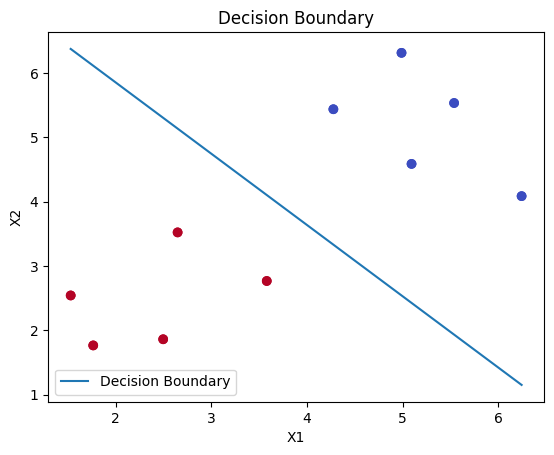

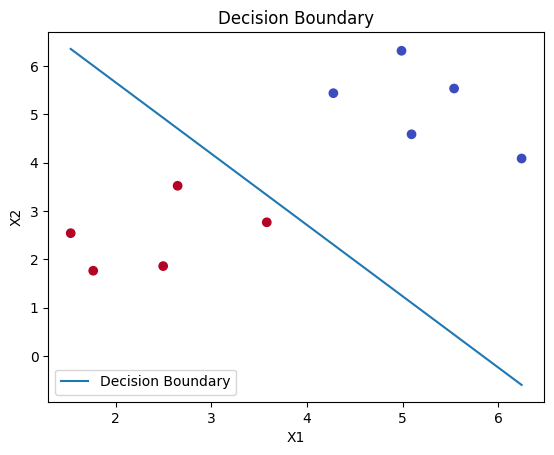

In [52]:
np.random.seed(42)

# Generate class 1 data points
class1_x = np.random.normal(2, 1, (5, 2))
class1_y = np.ones((5, 1))

# Generate class 2 data points
class2_x = np.random.normal(6, 1, (5, 2))
class2_y = -1 * np.ones((5, 1))

# Combine class 1 and class 2 data
X = np.vstack((class1_x, class2_x))
y = np.vstack((class1_y, class2_y))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)

# Instantiate the SimplePerceptron
perceptron = SimplePerceptron()

# Train the perceptron
perceptron.offline_training(X, y)

# Plot the decision boundary
perceptron.plot_decision_boundary(X, y)


# Train the perceptron
perceptron.online_training(X, y, learning_rate=0.001)

# Plot the decision boundary
perceptron.plot_decision_boundary(X, y)
